# Inferring behavioral strategies during decision making using GLM-HMMs
Decision-making is used to be often treated as a stable process: given the same stimulus, an animal is assumed to respond according to a fixed strategy with some added noise. However, growing evidence suggests that behavior is not from stationary. Instead, animals fluctuate between distinct internal states that can persist over many trials. Traditional models, such as the classic lapse model, capture errors as random, independent events, but fail to account for these structured, state-dependent fluctuations in behavior. This raises the question: can we infer these latent behavioral strategies directly from observed choices?

In this notebook, we address this question using the GLM-HMM framework, which combines a generalized linear model (GLM) with a hidden Markov model (HMM) to capture both how decisions change as a function of stimuli and how strategies evolve over time. We will show how to use choice data to recover hidden behavioral states using the NeMoS implementation of a Bernoulli GLM-HMM, replicating the main findings of Ashwood et al. (2022)<span id="cite1b"></span><a href="#ref1">[PENDING]</a>.

We have two main goals for this notebook:

1. How to use GLM-HMM to analyze real data / real world application.

    1.1 Showcase how to download and preprocess choice data from the IBL to fit it with a GLM-HMM
2. Demonstrate how to replicate published results using NeMoS

Importantly, throughout the notebook we will assume you already have a solid theoretical understanding of GLMs and GLM-HMMs. If you need an explanation, please refer to our tutorials on GLMs and GLM-HMMs. Moreover, if you already have a good understanding of GLM-HMMs and are interested in different heuristics you could use to overcome difficulties in the fitting process, please refer to our tutorial for fine-grain details of the fitting algorithm and different initialization methods you could use to ensure the best possible fit and thus description of your data under this model.

## GLM-HMMs
GLM-HMMs, also known as input-out HMM (Bengio & Frasconi, 1995) <span id="cite1b"></span><a href="#ref1">[PENDING]</a>, models are useful to analyze how hidden latent states affect observable behavioral (Ashwood et al., 2022) <span id="cite1b"></span><a href="#ref1">[1b]</a> and neural (Escola et al., 2011)<span id="cite1b"></span><a href="#ref1">[PENDING]</a> dynamics. These models are composed by an HMM governing the distribution over the latent states and state-specific GLMs, which specify the activity of the system at each state.

<center><img src="images/graphical_model.png" alt="Graphical model of GLM-HMM" width="800" /></center>

<div style="text-align: center;">
  Graphical model of a GLM-HMM. 
</div>

The state $z_t$ at time $t$ is only dependent on the previous one $z_{t-1}$. The observation $y_t$ is independent from all the others conditioned on the hidden state $z_t$.  Moreover, the observation is dictated by the GLM parameters $GLM_{z_t}$, conditioned on the state $z_t$. GLMs are models that describe how the output of a system $y_t$ varies as a function of input $x_t$ 

In this notebook, we will extract hidden behavioral states using observed behavior from a mouse (choices). Thanks to the GLM component, we will also see how these hidden states and observable predictors (stimulus intensity, previous action, win-stay lose-shift strategy) 

In all GLM-HMMs, the HMM component is fully defined by three elements: a state transition matrix, an initial probability vector and an emissions probability distribution (Bishop, 2006)<span id="cite1b"></span><a href="#ref1">[PENDING]</a>. A HMM with K hidden states has a $K \times K$ transition matrix that specifies the probability of transitioning from any state to any other,
\begin{align}
p(z_t=j\mid z_{t-1} = i) = A_{ij}
\end{align}
where $z_{t-1}$ and $z_t$ indicate the latent state at trials $t-1$ and $t$, respectively. The HMM also has a distribution over the initial states, given by a K-element vector $\pi$ whose elements sum to one:
\begin{align}
p(z_1 = i) = \boldsymbol{\pi}_i
\end{align}
Finally, the emissions probability describes the relationship between the state and the observation. In the case of GLM-HMMs, the emissions probability is a GLM (it can be, for example, a Bernoulli GLM); that is, a generalization of linear regression that allows to characterize how an output (behavior, neuronal activity) may vary as a function of an input.

A K-state GLM-HMM contains K independent GLMs, each defined by a weight vector specifying how inputs are integrated in that particular state to give rise to activity. These describe the state-dependent mapping from inputs to activity. So far, we have implemented a GLM with a Bernoulli observation mode i.e., a Bernoulli GLM.
\begin{equation}
y_t \mid \boldsymbol{x}, \boldsymbol{k} \sim Ber(f(-\boldsymbol{x}_t \cdot \boldsymbol{w}_k)) \\
\end{equation}
where $\boldsymbol{w}_k \in \mathbb{R}^M$ denotes the GLM weights for latent state $k \in {1,..,K}$. Thus, the probability of success ($y_t = 1$, which can correspond to a given choice in a binary set up, or a spike count for a time bin) given the input vector $\boldsymbol{x}_t$ is given by:
\begin{align}
p(y_t=1\mid\boldsymbol{x}_t, z_t = k)  = \frac{1}{1+exp(-\boldsymbol{x}_t \cdot \boldsymbol{w}_k)}
\end{align}
considering that the current implementation of GLM-HMM uses a logistic inverse link function.

## Setup

In [90]:
# Imports
import nemos as nmo
from nemos.glm_hmm import GLMHMM
nmo.GLMHMM = GLMHMM # this is the only way I got the GLM HMM module to work when using my own installation...I don't really know why but it won't be a problem when we release anyway

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
import pynapple as nap
import seaborn as sns
from notebook_utils import *

seed = 65  # Random seed for reproducibility
np.random.seed(seed)
jax.config.update("jax_enable_x64", True)

# Parameters for plotting
custom_params = {"axes.spines.right": False, "axes.spines.top": False}
sns.set_theme(style="ticks", palette="colorblind", font_scale=1.5, rc=custom_params)#, context="notebook")

## Download and preprocessing of data (pending until fully figured out importing from IBL)
[IBL dataset downloading process]

In [91]:
#design_matrix, y_raw, session = load_data("IBL/CSHL_008_processed.npz")

container = np.load("IBL/_unnormalized.npz", allow_pickle=True)
data = [container[key] for key in container]
design_matrix = data[1]
y_raw = data[2]
session = data[3]

## 01. Understanding the task structure: IBL decision-making task

<center><img src="images/IBL_edited.png" alt="Task schematic" width="500" /></center>

<div style="text-align: center;">

  Task illustration. Modified from IBL et al. (2021) 
   <span id="cite1b"></span><a href="#ref1">[PENDING]</a>.
</div>

We will analyze the IBL decision-making task, which is a variation of the two-alternative forced-choice perceptual detection task (IBL et al., 2021 <span id="cite1b"></span><a href="#ref1">[PENDING]</a>). During this task, a sinusoidal grating with varying contrast [0\%-100\%] appeared either at the right or left side of the screen. The goal for the mice was to indicate this side turning a little wheel so that this turn would accordingly move the stimuli to the center of the screen (Burgess et al. (2021) <span id="cite1b"></span><a href="#ref1">[PENDING]</a>. If the mice chose the side correctly, they would receive a water reward; if not, a noise burst and there would be a 1 second timeout. 

For the first 90 trials of each session, the stimulus appeared randomly on either side of the screen; after that, the stimulus would appear on one side with fixed probability 0.8 and alternate randomly every 20-100 trials. Same as in Ashwood et al., (2022)  <span id="cite1c"></span><a href="#ref1">[1c]</a>., we will only analyze the first 90 trials of each session (the ones with random appearance at either side).

First, let's see what the design matrix looks like. 

In [92]:
print(f"shape = {design_matrix.shape}")

shape = (5040, 3)


In [93]:
design_matrix

array([[-2.04963184e+00, -1.00000000e+00, -1.00000000e+00],
       [ 2.04861541e+00, -1.00000000e+00, -1.00000000e+00],
       [ 5.11772690e-01,  1.00000000e+00,  1.00000000e+00],
       ...,
       [ 2.04861541e+00,  1.00000000e+00, -1.00000000e+00],
       [-5.08215184e-04,  1.00000000e+00,  1.00000000e+00],
       [ 1.27562011e-01,  1.00000000e+00, -1.00000000e+00]],
      shape=(5040, 3))

The design matrix has shape (n_timepoints, n_predictors). 
- PREDICTOR 1 - stimuli: grating contrast and position: the absolute value indicates the intensity of the contrast, whilst the sign indicates whether it was shown at the left (-) or the right (+) of the animal.
- PREDICTOR 2 - previous choice: choice made by the animal in the immediate previous timepoint - simply repeat the choice. The choice is coded by the sign: left (-) or right (+)
- PREDICTOR 3 - win-stay lose-shift: if the previous choice was rewarded, then repeat the choice; conversely, shift. Also coded with the sign: left (-) or right (+)

If the animal was engaged with the task, the only predictor that should be relevant is PREDICTOR 1 - stimuli

Ashwood: We modeled the animals’ decision-making strategies using a GLM-HMM with four inputs: (1) the (signed) stimulus contrast, where positive values indicate a right-side grating and negative values indicate a left-side grating; (2) a constant offset or bias; (3) the animal’s choice on the previous trial; and (4) the stimulus side on the previous trial. A large weight on the animal’s previous choice gives rise to a strategy known as ‘perserveration’ in which the animal makes the same choice many times in a row, regardless of whether it receives a reward. A large weight on the previous stimulus side, which we refer to as the ‘win-stay, lose-switch’ regressor, gives rise to the well-known strategy in which the animal repeats a choice if it was rewarded and switches choices if it was not. Note that, for the IBL task in question, bias and trial history dependencies were suboptimal, meaning that the maximal reward strategy was to have a large weight on the stimulus and zero weights on the other three inputs.

In [94]:
print(f"input = {design_matrix}")    

input = [[-2.04963184e+00 -1.00000000e+00 -1.00000000e+00]
 [ 2.04861541e+00 -1.00000000e+00 -1.00000000e+00]
 [ 5.11772690e-01  1.00000000e+00  1.00000000e+00]
 ...
 [ 2.04861541e+00  1.00000000e+00 -1.00000000e+00]
 [-5.08215184e-04  1.00000000e+00  1.00000000e+00]
 [ 1.27562011e-01  1.00000000e+00 -1.00000000e+00]]


In [95]:
# plot of task variables
X_mouse = design_matrix 

The choices are coded with 0 (choice left) and 1 (choice right)

In [96]:
# Choices
choices_mouse = y_raw.flatten() # Convert to (n_timepoints,) | maybe I should pass the data
print(set(choices_mouse))

{np.int64(0), np.int64(1)}


In [97]:
choices_mouse[:10]

array([0, 1, 1, 1, 1, 1, 1, 0, 1, 1])

Importantly, do not do 3000 trials at once! Instead, they generally do several sessions of 100-300 trials, and we use all the sessions together to fit our model. For our model to be accurate, we need to tell it when our session boundaries are: we don't want it to compute all sessions as if they were one. 

With NeMoS, we have two ways of indicating the beginning of a new session. When using a design matrix and a choice vector that are Numpy objects, NeMoS treats NaNs either in the input matrix X or in the choice vector y as indicators of new sessions. You can also use a Pynapple Tsd or TsdFrame to demarcate sessions, which is what we will use now.

admonition !! careful, if your choice data contains nan values, they will be handled as new sessions, so make sure to address this promptly.

In [98]:
session

array(['0aed6875-9a5c-42d6-89b0-2c759ec76c00',
       '0aed6875-9a5c-42d6-89b0-2c759ec76c00',
       '0aed6875-9a5c-42d6-89b0-2c759ec76c00', ...,
       '66f20f92-171f-4cc5-aca9-69fc3cb6370f',
       '66f20f92-171f-4cc5-aca9-69fc3cb6370f',
       '66f20f92-171f-4cc5-aca9-69fc3cb6370f'],
      shape=(5040,), dtype='<U36')

In [99]:
# new_sess array
# Create array of 1s and 0s marking session boundaries
new_sess_mouse = np.zeros(len(session), dtype=int)
new_sess_mouse[0] = 1  # First entry is always 1

# Mark where session changes
new_sess_mouse[1:] = (session[1:] != session[:-1]).astype(int)

# Get positions of start of sessions
new_sess_pos = np.array(np.where(new_sess_mouse==1))
# Get length of session
sess_length = np.array(np.where(new_sess_mouse==1))[0][1] - 1 # substracting the starting trial

We will use a ```nap.Tsd``` now, because the choices are a 1-dimensional time series. To initialize it, we need the length of the series ```t``` and the data of the time series ```d``` (our choices vector). In addition to this, we can we can initialize our ```nap.Tsd``` with a ```time_support``` property, and this way store both the choices and the sessions information in the same object.

admonition When dealing with 2-dimensional time series, you should use the ```nap.TsdFrame``` object. If you want to learn more about Pynapple objects, check out [Pynapple documentation](https://pynapple.org/user_guide/01_introduction_to_pynapple.html).

In [100]:
choices_tsd = nap.Tsd(t = np.arange(choices_mouse.shape[0]), d=choices_mouse, time_support=nap.IntervalSet(start=new_sess_pos, end = new_sess_pos+ sess_length))

print(f"choices tsd \n {choices_tsd} \n")
print(f"time support\n {choices_tsd.time_support}")

choices tsd 
 Time (s)
----------  --
0.0          0
1.0          1
2.0          1
3.0          1
4.0          1
5.0          1
6.0          1
...
5033.0       1
5034.0       1
5035.0       1
5036.0       1
5037.0       1
5038.0       1
5039.0       1
dtype: int64, shape: (5040,) 

time support
 index    start    end
0        0.0      89.0
1        90.0     179.0
2        180.0    269.0
3        270.0    359.0
4        360.0    449.0
5        450.0    539.0
6        540.0    629.0
...      ...      ...
49       4410.0   4499.0
50       4500.0   4589.0
51       4590.0   4679.0
52       4680.0   4769.0
53       4770.0   4859.0
54       4860.0   4949.0
55       4950.0   5039.0
shape: (56, 2), time unit: sec.


## Fitting a GLM-HMM with NeMoS (Maximum Likelihood)
As mentioned above, we will use a Bernoulli GLM to model this mouse's choices. For this, we first you need to initialize the ```GLMHMM``` object. The only mandatory thing you have to declare is the number of states. In Ashwood et al. (2022) <span id="cite1b"></span><a href="#ref1">[PENDING]</a>, they found that most mice used 3 decision-making states when performing the task. Thus, in our case, we will initialize the ```GLMHMM``` object with 3 states. 

! admonition The default observation model for the GLM-HMM is this model is Bernoulli, but we also have Categorical (Multinomial), Poisson, Gamma, Negative Binomial and Gaussian available. Moreover, if desired, you can also set a different observation model of your choice. You can also personalize the inverse link function. Convexity non guaranteed for all likelihood functions, refer to Escola paper and also to the other notebook.

DONT EDIT, MIGHT CHANGE :)
If required, you can further personalize the ```GLMHMM``` object settings. Beyond the number of states, the observation model and the inverse link function, you can also initialization functions for to aid parameter estimation. 

If you don't set up any initialization settings, you would use the NeMoS defaults:
- ``"glm_params_init"``: ``"random"`` - small random coefficients, mean-rate intercept
- ``"scale_init"``: ``"constant"`` - scale initialized to 1.0
- ``"initial_proba_init"``: ``"uniform"`` - equal probability for all states
- ``"transition_proba_init"``: ``"sticky"`` - high self-transition probability (0.95)

Right now we will not use NeMoS defaults. Instead, we will use a special set of initial values, the same as in Ashwood et al. (2022) <span id="cite1b"></span><a href="#ref1">[PENDING]</a>, to replicate their results.

! admonition importance of choice of initial parameters in the context of GLM HMMs, link to other notebook

In [ ]:
n_states = 3

## Inits from ashwood - these should be downloaded at the beginning of the notebook
b = np.load('best_global_params/best_params_K_3.npz', allow_pickle=True)
initial_prob_ashwood = np.exp(b["arr_0"][0]).squeeze(0)
transition_prob_ashwood = np.exp(b["arr_0"][1]).squeeze(0)
glm_weights_ashwood = np.asarray(-b["arr_0"][2])[:,:,:3].T.squeeze(1)
intercept_ashwood = np.asarray(-b["arr_0"][2])[:,:,3].T.squeeze(0)

initial_prob_initial_guess_mouse = initial_prob_ashwood
transition_prob_initial_guess_mouse = transition_prob_ashwood
projection_weights_initial_guess_mouse = glm_weights_ashwood
intercept_initial_guess_mouse = intercept_ashwood


DESIGN_INPUT_TYPE = "Union[jnp.ndarray, FeaturePytree, nap.TsdFrame]"

from nemos.typing import Callable

def glm_params_funct(
    n_states: int, 
    X: DESIGN_INPUT_TYPE,
    y: jnp.ndarray, 
    inverse_link_function: Callable, 
    key: jax.random.PRNGKey, 
    glm_params_init = projection_weights_initial_guess_mouse, 
    intercept_init = intercept_initial_guess_mouse
): 
    return glm_params_init, intercept_initial_guess_mouse

def initial_proba_init_func(
    n_states: int, 
    X: DESIGN_INPUT_TYPE, 
    y: jnp.ndarray, 
    key: jax.random.PRNGKey, 
    initial_proba_init = initial_prob_initial_guess_mouse
): 
    return initial_proba_init

def transition_proba_init_func(
    n_states: int, 
    X: DESIGN_INPUT_TYPE, 
    y: jnp.ndarray, 
    key: jax.random.PRNGKey, 
    transition_proba_init = transition_prob_initial_guess_mouse
): 
    return transition_proba_init

init_dic = {
    "glm_params_init":glm_params_funct,  # Uniform initial state distribution
    "initial_proba_init": initial_proba_init_func,  # Random GLM weights
    "transition_proba_init": transition_proba_init_func,  # Initial noise variances,
    "scale_init" : "constant"
}

model = nmo.glm_hmm.GLMHMM(
    n_states,
regularizer = "Ridge")
 #   regularizer_strength = 1/(2*(1000**2))
#)#, initialization_funcs=init_dic)

print(model)

GLMHMM(
    n_states=3,
    observation_model=BernoulliObservations(),
    inverse_link_function=logistic,
    regularizer=UnRegularized(),
    solver_name='GradientDescent[optimistix]',
    initialization_funcs={'glm_params_init': <function random_glm_params_init at 0x12d53d080>, 'scale_init': <function constant_scale_init at 0x12d53c900>, 'transition_proba_init': <function sticky_transition_proba_init at 0x12d53c360>, 'initial_proba_init': <function uniform_initial_proba_init at 0x12d53d4e0>},
    initialization_kwargs={'glm_params_init': {}, 'scale_init': {}, 'transition_proba_init': {}, 'initial_proba_init': {}},
    maxiter=1000,
    tol=1e-08
)


Once we created our object, we can fit our model. The fit function takes two mandatory arguments: the design matrix which we discussed above and the ```choices_tsd```.

! admonition on how to choose a good initialization of parameters
Probably point them to the other notebook

In [102]:
model.fit(X_mouse, choices_tsd)
# init_params -> check docstring

,n_states,3
,observation_model,BernoulliObservations()
,inverse_link_function,<function log...t 0x12d15e700>
,regularizer,UnRegularized()
,regularizer_strength,None
,dirichlet_prior_alphas_init_prob,None
,dirichlet_prior_alphas_transition,None
,solver_name,'GradientDescent[optimistix]'
,solver_kwargs,{}
,initialization_funcs,"{'glm_params_init': <function ran...t 0x12d53d080>, 'initial_proba_init': <function uni...t 0x12d53d4e0>, 'scale_init': <function con...t 0x12d53c900>, 'transition_proba_init': <function sti...t 0x12d53c360>}"
,initialization_kwargs,"{'glm_params_init': {}, 'initial_proba_init': {}, 'scale_init': {}, 'transition_proba_init': {}}"


If we want to see our glm-hmm parameters, we can call ```model.coef_```. This will output the coefficients of the glm per state, with shape (n_features, n_states)

In [103]:
model.coef_

Array([[ 9.58022389e-01,  7.17531972e+00,  5.40288796e+00],
       [ 1.78174835e+00,  2.85100888e-01, -2.09030113e-01],
       [ 5.79501808e-03, -2.11542895e-02,  2.70358480e-01]],      dtype=float64)

Similarly, to see the intercept, we can call ```model.intercept_```, which will output the intercept per state. The shape of this object is (n_states)

In [104]:
model.intercept_

Array([ 0.1000706 ,  0.69246223, -0.85061322], dtype=float64)

### Plot 2e: glm weights

Ashwood: Inferred GLM weights for the three-state model. State 1 weights have a large weight on the stimulus, indicating an ‘engaged’ or high-accuracy state. In states 2 and 3, the stimulus weight is small, and the bias weights give rise to large leftward (state 2) and rightward (state 3) biases.

GLM weights, which define how the animal makes decisions in each state (Fig. 2e). One of these GLMs (‘state 1’) had a large weight on the stimulus and negligible weights on other inputs, giving rise to high-accuracy performance on the task (Fig. 2f). The other two GLMs (‘state 2’ and ‘state 3’), by comparison, had smaller weights on the stimulus and relatively large bias weights.

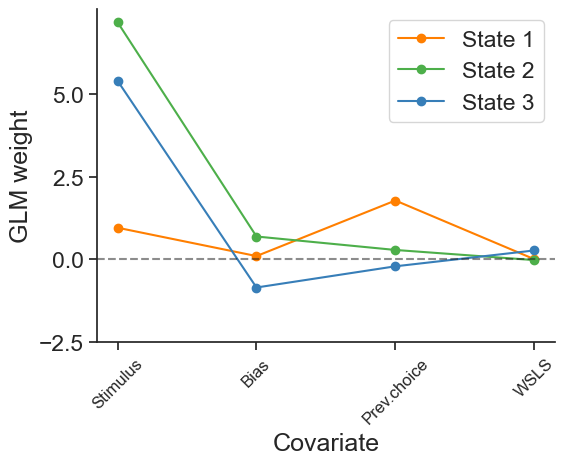

In [105]:
def plot_glm_weights(
    model
):
    plt.figure(figsize=(6, 5))
    colors = ["#ff7f00", "#4daf4a", "#377eb8"]

    n_features = model.coef_.shape[0]+1 # add 1 for the intercept
    n_states = model.coef_.shape[1]
    
    # Change order of weights so output matches Ashwood et al. (2022) 2e plot
    recovered_weights = np.zeros((n_features,n_states)) 
    recovered_weights[0,:] = model.coef_[0,:] # stimulus
    recovered_weights[1,:] = model.intercept_ # bias
    recovered_weights[2:,:] = model.coef_[1:,:] # prev choice, wsls
    
    # Labels for plot matching Ashwood et al. (2022) 2e plot
    X_labels = ["Stimulus", "Bias", "Prev.choice", "WSLS"]

    for state in range(n_states):
        plt.plot(
            range(n_features),
            recovered_weights[:, state],
            color=colors[state],
            marker="o",
            lw=1.5,
            label="State {}".format(state + 1),
            linestyle="-",
        )
            
    plt.yticks([-2.5, 0, 2.5, 5])
    plt.ylabel("GLM weight")
    plt.xlabel("Covariate")
    plt.xticks([i for i in range(n_features)], X_labels, fontsize=12, rotation=45)
    plt.axhline(y=0, color="k", alpha=0.5, ls="--")
    plt.legend()
    plt.tight_layout()
    plt.show()
    return None

plot_glm_weights(model)

### Plot 2d: transition matrix
Ashwood: The transition matrix for the fitted three-state model describes the transition probabilities among three different states, each of which corresponds to a different decision-making strategy (Fig. 2d). Large entries along the diagonal of this matrix, ranging between 0.94 and 0.98, indicate a high probability of remaining in the same state for multiple trials.

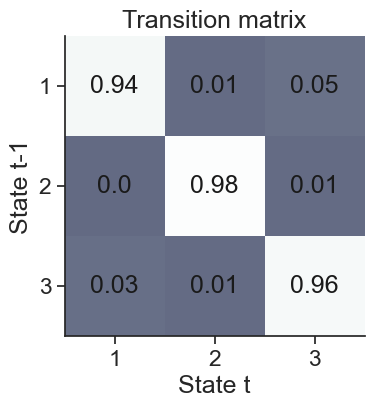

In [106]:
n_decimals = 2

fig = plt.figure(figsize=(8, 3))

plt.imshow(model.transition_prob_, vmin=-0.8, vmax=1, cmap='bone')

for i in range(model.transition_prob_.shape[0]):
    for j in range(model.transition_prob_.shape[1]):
        text = plt.text(j, i, str(np.around(model.transition_prob_[i, j], decimals=n_decimals))[:n_decimals+2], ha="center", va="center",
                        color="k")
plt.xlim(-0.5, n_states - 0.5)
plt.xticks(range(0, n_states), ('1', '2', '3'))
plt.yticks(range(0, n_states), ('1', '2', '3'))
plt.ylim(n_states - 0.5, -0.5)
plt.ylabel("State t-1",)
plt.xlabel("State t")
plt.title("Transition matrix")

plt.subplots_adjust(0, 0, 1, 1)

### Plot 2g: Psychometric curves
To understand how different states "affect" (change wording) choice behavior, we can use a psychometric curve.

Ashwood: 
We can visualize the decision-making strategies associated with these states by plotting the corresponding psychometric curves. (Fig. 2g), which show the probability of a rightward choice as a function of the stimulus, conditioned on both previous choice and reward. The steep curve observed in state 1, which corresponds to the mouse achieving near-perfect performance on high-contrast stimuli, led us to adopt the name ‘engaged’ to describe this state. By comparison, the psychometric curves for states 2 and 3 reflected large leftward and rightward biases, respectively. They also had relatively large dependence on previous choice and reward, as indicated by the gap between solid and dashed lines.

Using the fit GLM-HMM parameters for this animal and the true sequence of stimuli presented to the mouse, we generated a time series with the same number of trials as those that the example mouse had in its dataset. At each trial, regardless of the true stimulus presented, we calculated pt(“R”) for each of the nine possible stimuli by averaging the per-state psychometric curves of g and weighting by the appropriate row in the transition matrix (depending on the sampled latent state at the previous trial). Finally, we averaged the per-trial psychometric curves across all trials to obtain the curve that is shown in black, whereas the empirical choice data of the mouse are shown in red, as are 95% confidence intervals (n between 530 and 601, depending on stimulus value). acc., accuracy.

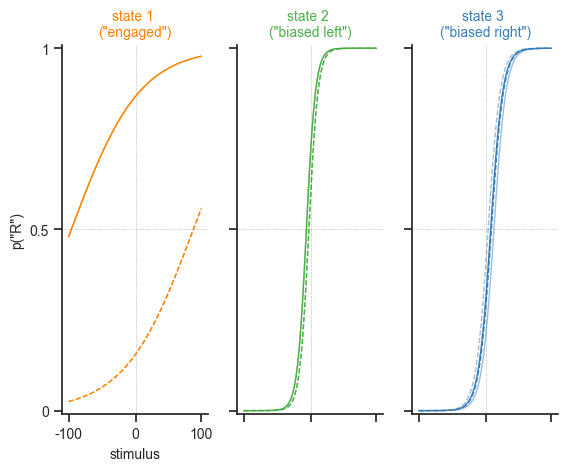

In [107]:
from scipy.special import expit
from nemos.glm_hmm.utils import compute_rate_per_state

class PARAMS:
    def __init__(self, coef, intercept):
        self.coef = coef
        self.intercept = intercept
param = PARAMS(model.coef_, model.intercept_)

def get_prob_right(model, inpt, k, pc, wsls):
    # pending to make this more elegant with NeMoS
    # stim vector
    min_val_stim = np.min(inpt[:, 0])
    max_val_stim = np.max(inpt[:, 0])
    
    stim_vals = np.arange(min_val_stim, max_val_stim, 0.05)
    
    # create input matrix - cols are stim, pc, wsls, bias
    x = np.array([
        stim_vals,
        np.repeat(pc, len(stim_vals)),
        np.repeat(wsls, len(stim_vals)),
    ]).T        
    
    return stim_vals, compute_rate_per_state(x, param, model.inverse_link_function)[:,k] 

stim_vals, prob_right_max  = get_prob_right(model, design_matrix, 0, 1, 1)
_, prob_right_min  = get_prob_right(model, design_matrix, 0, -1, -1)

cols = [
        '#ff7f00', '#4daf4a', '#377eb8', '#f781bf', '#a65628', '#984ea3',
        '#999999', '#e41a1c', '#dede00'
]
K = 3
for k in range(K):
    plt.subplot(1, 3, k+1)
    # USE GLM WEIGHTS TO GET PROB RIGHT
    stim_vals, prob_right_max = get_prob_right(model, design_matrix, k, 1, 1)
    _, prob_right_min = get_prob_right(model, design_matrix, k, -1, -1)
    
    plt.plot(stim_vals,
                prob_right_max,
                '-',
                color=cols[k],
                alpha=1,
                lw=1,
                zorder=5)  # went R and was rewarded on previous trial
    
    plt.plot(stim_vals,
                get_prob_right(model, design_matrix, k, -1, 1)[1],
                '--',
                color=cols[k],
                alpha=0.5,
                lw=1)  # went L and was not rewarded on previous trial
    plt.plot(stim_vals,
                get_prob_right(model, design_matrix, k, 1, -1)[1],
                '-',
                color=cols[k],
                alpha=0.5,
                lw=1,
                markersize=3)  # went R and was not rewarded on previous trial
    
    plt.plot(stim_vals, prob_right_min, '--', color=cols[k], alpha=1,
                lw=1)  # went L and was rewarded on previous trial
    
    plt.xticks([min(stim_vals), 0, max(stim_vals)],
                labels=['', '', ''],
                fontsize=10)
    
    plt.yticks([0, 0.5, 1], ['', '', ''], fontsize=10)
    plt.ylabel('')
    plt.xlabel('')
    if k == 0:
        plt.title("state 1 \n(\"engaged\")", fontsize=10, color=cols[k])
        plt.xticks([min(stim_vals), 0, max(stim_vals)],
                    labels=['-100', '0', '100'],
                    fontsize=10)
        plt.yticks([0, 0.5, 1], ['0', '0.5', '1'], fontsize=10)
        plt.ylabel('p("R")', fontsize=10)
        plt.xlabel('stimulus', fontsize=10)
    if k == 1:
        plt.title("state 2 \n(\"biased left\")",
                    fontsize=10,
                    color=cols[k])
        plt.xticks([min(stim_vals), 0, max(stim_vals)],
                    labels=['', '', ''],
                    fontsize=10)
        plt.yticks([0, 0.5, 1], ['', '', ''], fontsize=10)
    if k == 2:
        plt.title("state 3 \n(\"biased right\")",
                    fontsize=10,
                    color=cols[k])
        plt.xticks([min(stim_vals), 0, max(stim_vals)],
                    labels=['', '', ''],
                    fontsize=10)
        plt.yticks([0, 0.5, 1], ['', '', ''], fontsize=10)
    plt.axhline(y=0.5, color="k", alpha=0.45, ls=":", linewidth=0.5)
    plt.axvline(x=0, color="k", alpha=0.45, ls=":", linewidth=0.5)
    plt.gca().spines['right'].set_visible(False)
    plt.gca().spines['top'].set_visible(False)
    plt.ylim((-0.01, 1.01))
plt.show()
    

### Plot 2f: accuracy per state
Ashwood: Overall accuracy of this mouse (gray) and accuracy for each of the three states. g, Psychometric curve for each state, conditioned on previous reward and previous choice.

Although this mouse had an overall accuracy of 80%, it achieved 90% accuracy in the engaged state compared to only 60% and 58% accuracy in the two biased states (Fig. 2f).

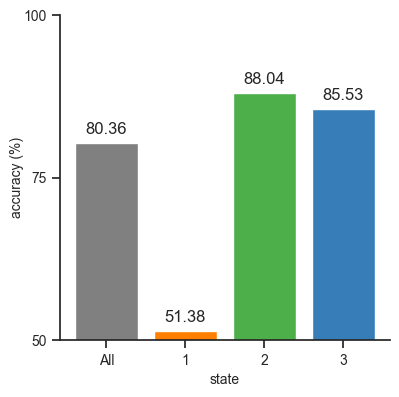

In [108]:
unnormalized_inpt, _, _ = load_data("IBL/CSHL_008" +
                                        '_unnormalized.npz')
accuracies_to_plot = []
not_zero_loc = np.where(unnormalized_inpt[:, 0] != 0)[0] # unnormalized input 

correct_ans = (np.sign(unnormalized_inpt[not_zero_loc, 0]) + 1) / 2
acc = np.sum(choices_mouse[not_zero_loc] == correct_ans) / len(correct_ans)
accuracies_to_plot.append(acc) # Append total accuracy

for state in range(n_states): # Append accuracy per state
    # index of time points where the most likely state is 0
    #idx_of_interest = np.where(model.decode_state(X_mouse,choices_mouse, state_format = "index")==state) 
    # viterbi yields a slightly different result
    
    posterior_probs = model.smooth_proba(X_mouse, choices_mouse)
    idx_of_interest = np.where(posterior_probs[:, state] >= 0.9)[0]
    
    # viterbi to get label and filter posterior to pick the states
    # do both and explain differences?
    
    inpt_this_state, unnormalized_inpt_this_state, y_this_state = \
        design_matrix[idx_of_interest, :], unnormalized_inpt[idx_of_interest, :], \
        choices_mouse[idx_of_interest]

    not_zero_loc = np.where(unnormalized_inpt_this_state[:, 0] != 0)[0]
    
    correct_ans = (np.sign(unnormalized_inpt_this_state[not_zero_loc, 0]) + 1) / 2
    acc = np.sum(y_this_state[not_zero_loc] == correct_ans) / len(correct_ans)
    accuracies_to_plot.append(acc)
    
cols = [
        '#ff7f00', '#4daf4a', '#377eb8', '#f781bf', '#a65628', '#984ea3',
        '#999999', '#e41a1c', '#dede00'
    ]

fig = plt.figure(figsize=(6, 5))
plt.subplots_adjust(left=0.4, bottom=0.3, right=0.95, top=0.95)
for z, acc in enumerate(accuracies_to_plot):
    if z == 0:
        col = 'grey'
    else:
        col = cols[z - 1]
    plt.bar(z, acc*100, width=0.8, color=col)
    plt.text(z, acc*100 + 1, f"{acc*100:.2f}", ha='center', va='bottom', fontsize=12)

plt.ylim((50, 100))
plt.xticks([0, 1, 2, 3], ['All', '1', '2', '3'], fontsize=10)
plt.yticks([50, 75, 100], fontsize=10)
plt.xlabel('state', fontsize=10)
plt.ylabel('accuracy (%)', fontsize=10, labelpad=-0.5)
plt.gca().spines['right'].set_visible(False)
plt.gca().spines['top'].set_visible(False)
plt.show()

### 3a. Posterior state probabilities
We can also show the posterior state probabilities.

Ashwood: Posterior state probabilities for three example sessions, revealing high levels of certainty about the mouse’s internal state and showing that states typically persisted for many trials in a row.

To gain insight into the temporal structure of decision-making behavior, we used the fitted three-state model to compute the  posterior probability over the mouse’s latent state across all trials (Fig. 3). The resulting state trajectories reflect our posterior beliefs about the animal’s internal state on every trial, given the entire sequence of observed inputs and choices during a session (see Methods).

/Users/camilamaura/coding_projects/glm_hmm_notebook/.venv/lib/python3.12/site-packages/pynapple/core/utils.py:198: UserWarning: Converting 'd' to numpy.array. The provided array was of type 'ArrayImpl'.
  warnings.warn(


IndexError: index 0 is out of bounds for axis 0 with size 0

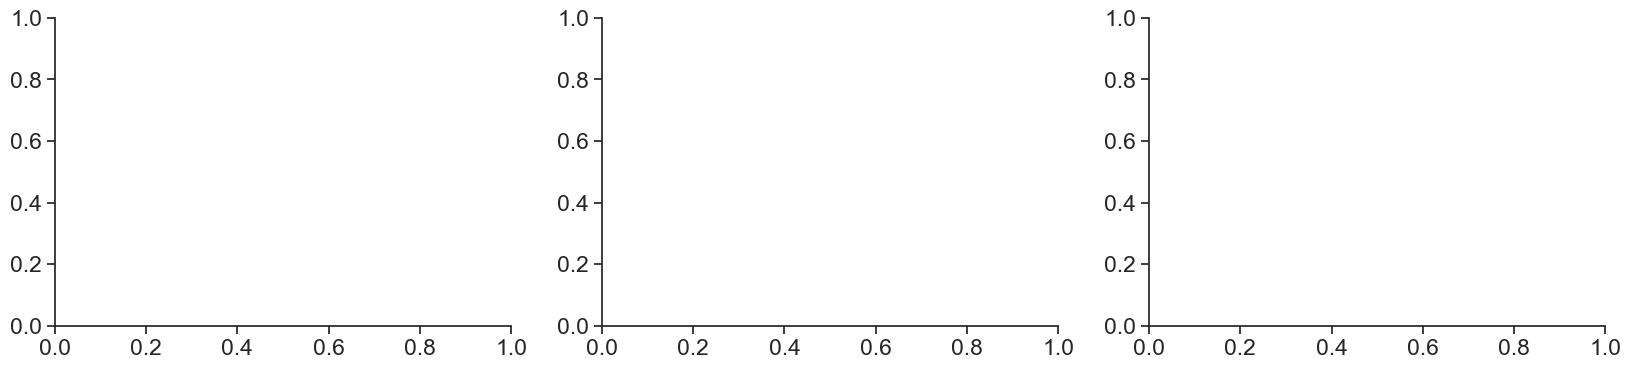

In [109]:
sess_to_plot = ["CSHL_008-2019-04-29-001", "CSHL_008-2019-08-07-001",
                    "CSHL_008-2019-05-28-001"]

sess_ex_1 = np.where(session == sess_to_plot[0])
sess_ex_2 = np.where(session == sess_to_plot[1])
sess_ex_3 = np.where(session == sess_to_plot[2])

sess_examples = [sess_ex_1, sess_ex_2, sess_ex_3]
posteriors = model.smooth_proba(X_mouse, choices_tsd)

colors =['#ff7f00', '#4daf4a', '#377eb8']
fig, ax = plt.subplots(1,3,figsize=(20, 4))
for example_session in range(len(ax)):
    for state in range(3):
        ax[example_session].plot(posteriors[sess_examples[example_session][0][0]:sess_examples[example_session][0][0]+90][:, state],
                    label="State " + str(state + 1), lw=3,
                    color=colors[state])
        ax[example_session].set_title("Example session " + str(example_session + 1))#, fontsize=10)
        if example_session == 0:
            ax[example_session].set_xticks(
                [
                    sess_examples[example_session][0][0], 
                    sess_examples[example_session][0][0] + 45, 
                    sess_examples[example_session][0][0] + 90
                ], 
                [
                    "0", 
                    "45", 
                    "90"
                ], 
            )
            ax[example_session].set_xlabel("Trial #")
            ax[example_session].set_yticks(
                [0, 0.5, 1], 
                ["0", "0.5", "1"], 
            )
        else:
            ax[example_session].set_xticks(
                [
                    sess_examples[example_session][0][0], 
                    sess_examples[example_session][0][0] + 45, 
                    sess_examples[example_session][0][0] + 90
                ], 
                [
                    " ", 
                    " ", 
                    " "
                ], 
            )
            ax[example_session].set_yticks(
                [0, 0.5, 1], 
                [" ", " ", " "], 
            )

## should add fraction of occupancy and fraction of session with number of state changes
Ashwood: Moreover, the mouse changed state at least once within a session in roughly 71% of all 90-trial sessions and changed multiple times in 59% of sessions (Fig. 3e). This rules out the possibility that the states merely reflect the use of different strategies on different days. Rather, the mouse tended to remain in an engaged, high-performance state for tens of trials at a time, with lapses arising predominantly during interludes when it adopted a left-biased or right-biased strategy for multiple trials in a row. The multi-state GLM-HMM thus provides a very different portrait of mouse decision-making behavior than the basic GLM or lapse model.

## Conclusion
conclusionary conclusion la conclusión que concluyo c'est fini

follow state descriptions in the paper
if you dont segment the paper then you would not be able to see some effects (see in what way they do that) -> explain at the very begining as a motivation and in the end as an interpretation -> why they thought to use this method

## Other resources
- ssm tutorial: https://github.com/zashwood/ssm/blob/master/notebooks/2b%20Input%20Driven%20Observations%20(GLM-HMM).ipynb

## References
<a id="ref1a"><a href="#cite1a">[1a]</a> Ashwood, Z. C., Roy, N. A., Stone, I. R., Laboratory, I. B., Urai, A. E., Churchland, A. K., Pouget, A., & Pillow, J. W. (2022). Mice alternate between discrete strategies during perceptual decision-making. Nature Neuroscience, 25(2), 201–212.

The International Brain Laboratory, Aguillon-Rodriguez, V., Angelaki, D., Bayer, H., Bonacchi, N., Carandini, M., Cazettes, F., Chapuis, G., Churchland, A. K., Dan, Y., Dewitt, E., Faulkner, M., Forrest, H., Haetzel, L., Häusser, M., Hofer, S. B., Hu, F., Khanal, A., Krasniak, C., … Zador, A. M. (2021). Standardized and reproducible measurement of decision-making in mice. eLife, 10, e63711. https://doi.org/10.7554/eLife.63711

Burgess, C. P., Lak, A., Steinmetz, N. A., Zatka-Haas, P., Bai Reddy, C., Jacobs, E. A. K., Linden, J. F., Paton, J. J., Ranson, A., Schröder, S., Soares, S., Wells, M. J., Wool, L. E., Harris, K. D., & Carandini, M. (2017). High-Yield Methods for Accurate Two-Alternative Visual Psychophysics in Head-Fixed Mice. Cell Reports, 20(10), 2513–2524. https://doi.org/10.1016/j.celrep.2017.08.047

Escola, S., Fontanini, A., Katz, D., & Paninski, L. (2011). Hidden Markov models for the stimulus-response relationships of multistate neural systems. Neural Computation, 23(5), 1071–1132. https://doi.org/10.1162/NECO_a_00118

Bengio, Y., & Frasconi, P. (1995). An input-output HMM architecture. In G. Tesauro, D. S. Touretzky, & T. K. Leen (Eds.), Advances in neural information processing systems (Vol. 7, pp. 427–434). MIT Press.

Bishop, C. M. (2006). Pattern recognition and machine learning. Springer.


model:
<a id="ref1"></a><a href="#cite1a">[1a]</a> <a href="#cite1b">[1b]</a> <a href="#cite1c">[1c]</a> <a href="#cite1d">[1d]</a> Pillow, J. W., Shlens, J., Paninski, L., Sher, A., Litke, A. M., Chichilnisky, E. J., & Simoncelli, E. P. (2008). Spatio-temporal correlations and visual signalling in a complete neuronal population. Nature, 454(7207), 995-999. https://doi.org/10.1038/nature07140